In [21]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['STZhongsong']
plt.rcParams['axes.unicode_minus'] = False

import time
import threading
from filecmp import cmp
import os

timeA = []
timeB = []
checkpoint_error = []
timeoutpointA_error = []
timeoutpointB_error = []

def print_red(content:str):
    print("\033[0;31;40m%s\033[0m" % content)
def print_cyan(content:str):
    print("\033[0;36;40m%s\033[0m" % content)

def testA(order:int, timelimit:float):
    start = time.time()
    os.system("test_AVL\\test_AVL.exe <input\\%d.in >test_AVL\\output\\%d.out" % (order, order))
    cost = time.time() - start
    timeA.append(cost)
    if cost < timelimit:
        print("程序A成功输出！用时%fs！" % cost)

def testB(order:int, timelimit:float):
    start = time.time()
    os.system("test_splay\\test_splay.exe <input\\%d.in >test_splay\\output\\%d.out" % (order, order))
    cost = time.time() - start
    timeB.append(cost)
    if cost < timelimit:
        print("程序B成功输出！用时%fs！" % cost)

def check(order:int, timelimit:float):
    global checkpoint_error
    print("数据点：%d" % order)

    threadA = threading.Thread(target = testA, args = (order, timelimit,))
    start = time.time()
    threadA.start()
    threadA.join(timelimit * 2)
    cost = time.time() - start
    if cost > timelimit * 2:
        print_red("A程序严重超时！")
        timeoutpointA_error.append(order)
    elif cost > timelimit:
        print_cyan("A程序超时！用时%fs！" % cost)
        timeoutpointA_error.append(order)

    threadB = threading.Thread(target = testB, args = (order, timelimit,))
    start = time.time()
    threadB.start()
    threadB.join(timelimit * 2)
    cost = time.time() - start
    if cost > timelimit * 2:
        print_red("B程序严重超时！")
        timeoutpointB_error.append(order)
    elif cost > timelimit:
        print_cyan("B程序超时！用时%fs！" % cost)
        timeoutpointB_error.append(order)

    if cmp("test_AVL\\output\\%d.out" % order, "test_splay\\output\\%d.out" % order):
        print("通过！")
    else:
        checkpoint_error.append(order)
        print_red("输出不一致！")
    print()

for i in range(1, 401):
    check(i, 2.5)

数据点：1
程序A成功输出！用时0.043081s！
程序B成功输出！用时0.037076s！
通过！

数据点：2
程序A成功输出！用时0.048147s！
程序B成功输出！用时0.042208s！
通过！

数据点：3
程序A成功输出！用时0.049144s！
程序B成功输出！用时0.052062s！
通过！

数据点：4
程序A成功输出！用时0.053375s！
程序B成功输出！用时0.058950s！
通过！

数据点：5
程序A成功输出！用时0.068142s！
程序B成功输出！用时0.067912s！
通过！

数据点：6
程序A成功输出！用时0.072599s！
程序B成功输出！用时0.079634s！
通过！

数据点：7
程序A成功输出！用时0.081760s！
程序B成功输出！用时0.091832s！
通过！

数据点：8
程序A成功输出！用时0.089859s！
程序B成功输出！用时0.105052s！
通过！

数据点：9
程序A成功输出！用时0.123466s！
程序B成功输出！用时0.175796s！
通过！

数据点：10
程序A成功输出！用时0.117898s！
程序B成功输出！用时0.119551s！
通过！

数据点：11
程序A成功输出！用时0.122643s！
程序B成功输出！用时0.137001s！
通过！

数据点：12
程序A成功输出！用时0.128999s！
程序B成功输出！用时0.137005s！
通过！

数据点：13
程序A成功输出！用时0.139034s！
程序B成功输出！用时0.159298s！
通过！

数据点：14
程序A成功输出！用时0.141656s！
程序B成功输出！用时0.161688s！
通过！

数据点：15
程序A成功输出！用时0.166261s！
程序B成功输出！用时0.187797s！
通过！

数据点：16
程序A成功输出！用时0.185941s！
程序B成功输出！用时0.216105s！
通过！

数据点：17
程序A成功输出！用时0.184429s！
程序B成功输出！用时0.228987s！
通过！

数据点：18
程序A成功输出！用时0.198664s！
程序B成功输出！用时0.219405s！
通过！

数据点：19
程序A成功输出！用时0.200184s！
程序B成功输出！用

In [23]:
ns = np.linspace(1, 1000000, 100, dtype = int)

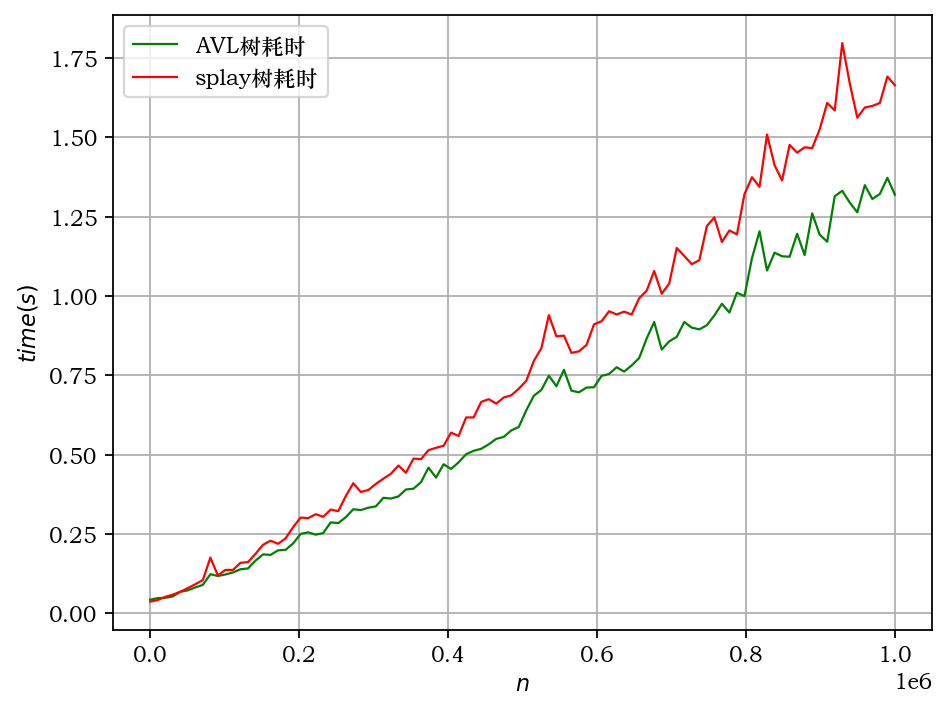

In [24]:

fig = plt.figure(dpi = 160.0)
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
plt.plot(ns, np.array(timeA)[:100], color = 'g', linewidth = 1, label = 'AVL树耗时')
plt.plot(ns, np.array(timeB)[:100], color = 'r', linewidth = 1, label = 'splay树耗时')
ax.set_xlabel("$n$")
ax.set_ylabel("$time(s)$")
ax.grid(visible = 1, which = 'major')
plt.legend(loc = 'best')
plt.show()

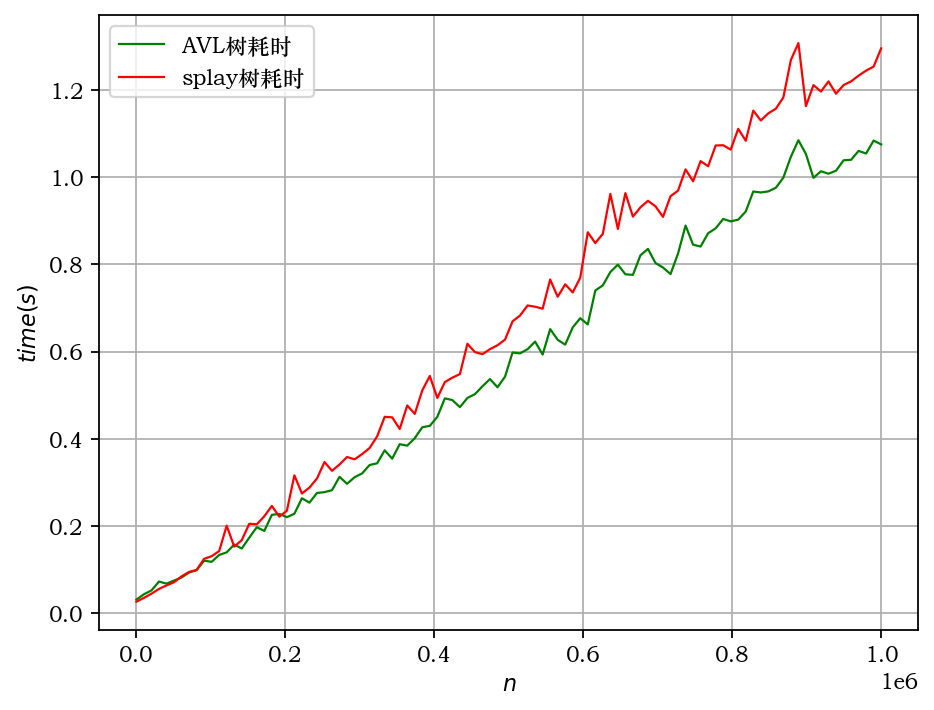

In [25]:
fig = plt.figure(dpi = 160.0)
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
plt.plot(ns, np.array(timeA)[100:200], color = 'g', linewidth = 1, label = 'AVL树耗时')
plt.plot(ns, np.array(timeB)[100:200], color = 'r', linewidth = 1, label = 'splay树耗时')
ax.set_xlabel("$n$")
ax.set_ylabel("$time(s)$")
ax.grid(visible = 1, which = 'major')
plt.legend(loc = 'best')
plt.show()

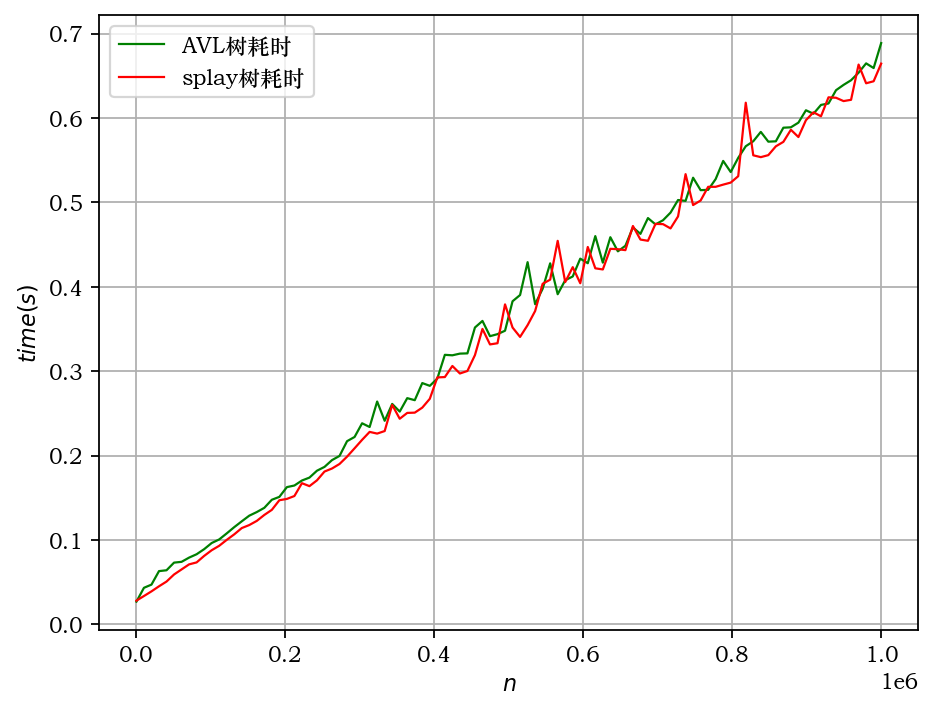

In [26]:
fig = plt.figure(dpi = 160.0)
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
plt.plot(ns, np.array(timeA)[200:300], color = 'g', linewidth = 1, label = 'AVL树耗时')
plt.plot(ns, np.array(timeB)[200:300], color = 'r', linewidth = 1, label = 'splay树耗时')
ax.set_xlabel("$n$")
ax.set_ylabel("$time(s)$")
ax.grid(visible = 1, which = 'major')
plt.legend(loc = 'best')
plt.show()

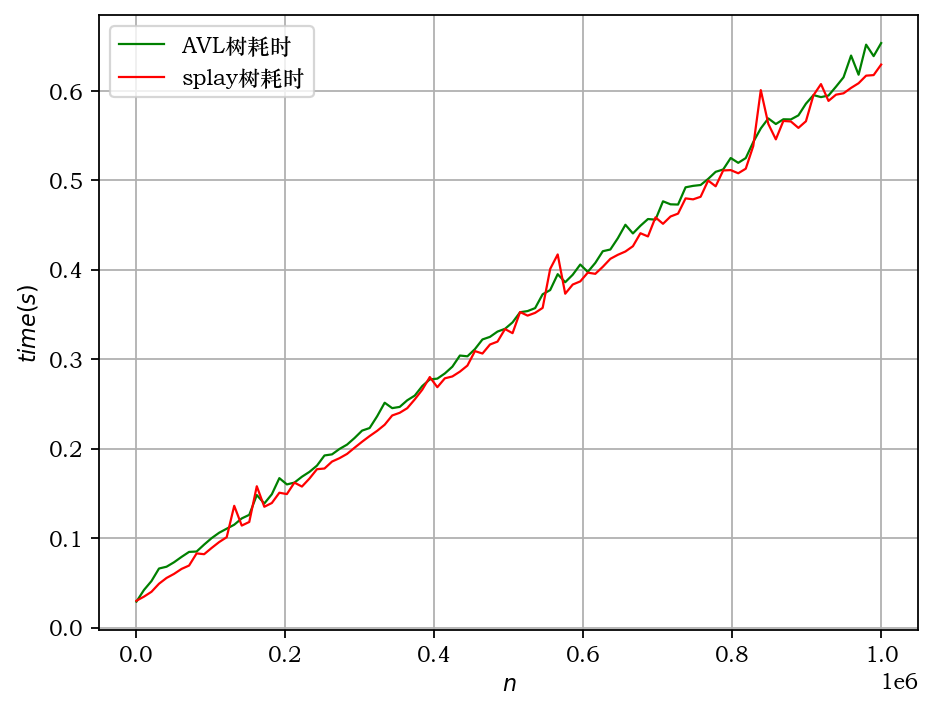

In [27]:
fig = plt.figure(dpi = 160.0)
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
plt.plot(ns, np.array(timeA)[300:400], color = 'g', linewidth = 1, label = 'AVL树耗时')
plt.plot(ns, np.array(timeB)[300:400], color = 'r', linewidth = 1, label = 'splay树耗时')
ax.set_xlabel("$n$")
ax.set_ylabel("$time(s)$")
ax.grid(visible = 1, which = 'major')
plt.legend(loc = 'best')
plt.show()

In [28]:
if len(checkpoint_error) == 0:
    print("A，B程序输出均一致！")
else:
    print("结果错误数据点：")
    print(checkpoint_error)

if len(timeoutpointA_error) != 0:
    print("A超时数据点：")
    print(timeoutpointA_error)

if len(timeoutpointB_error) != 0:
    print("B超时数据点：")
    print(timeoutpointB_error)

A，B程序输出均一致！
